# Marketing Funnel & Conversion Performance Analysis

**Objective:** Analyze a marketing funnel dataset to uncover conversion rates, drop-off points,
channel performance, revenue performance, and lead-to-customer conversion — culminating in
data-driven business recommendations.

**Sections**
1. Data Loading & Cleaning
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Conversion (Funnel) Analysis
5. Drop-off Analysis
6. Channel Analysis
7. ROI Analysis
8. Revenue Analysis
9. Final Business Insights


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)


## 1. Data Loading & Cleaning

In [2]:
df = pd.read_csv("../data/marketing_funnel.csv")
df["Date"] = pd.to_datetime(df["Date"])
print(f"Shape: {df.shape}")
df.head()


Shape: (2400, 19)


,Date,Campaign,Marketing Channel,Impressions,Clicks,CTR,Landing Page Visits,Leads,Qualified Leads,Customers,Conversion Rate,Revenue,Cost,ROI,Country,Device,Age Group,Gender,Campaign Type
0,2024-01-01,Influencer Collab,Affiliate,20802,555,2.6680,465,143,88,21,0.1010,2227.04,273.66,713.80,United States,Mobile,25-34,Female,Conversion
1,2024-01-01,Anniversary Sale,TikTok Ads,15192,788,5.1869,626,156,59,26,0.1711,1372.69,457.06,200.33,United Kingdom,Mobile,35-44,Male,Retargeting
2,2024-01-01,Back to School,Affiliate,15831,553,3.4931,491,143,59,22,0.1390,1742.90,275.66,532.26,India,Mobile,18-24,Male,Retargeting
3,2024-01-01,Flash Weekend Deal,YouTube Ads,18672,724,3.8775,573,127,63,15,0.0803,2351.97,661.10,255.77,India,Desktop,45-54,Female,Awareness
4,2024-01-01,Loyalty Rewards Push,YouTube Ads,17984,530,2.9471,413,108,57,17,0.0945,2464.42,448.96,448.92,United Kingdom,Desktop,45-54,Female,Consideration


In [3]:
# Data types and missing values
print(df.info())
print("\nMissing values per column:")
print(df.isna().sum())


<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 2400 non-null   datetime64[us]
 1   Campaign             2400 non-null   str           
 2   Marketing Channel    2400 non-null   str           
 3   Impressions          2400 non-null   int64         
 4   Clicks               2400 non-null   int64         
 5   CTR                  2400 non-null   float64       
 6   Landing Page Visits  2400 non-null   int64         
 7   Leads                2400 non-null   int64         
 8   Qualified Leads      2400 non-null   int64         
 9   Customers            2400 non-null   int64         
 10  Conversion Rate      2400 non-null   float64       
 11  Revenue              2400 non-null   float64       
 12  Cost                 2400 non-null   float64       
 13  ROI                  2400 non-null   float64

In [4]:
# Basic sanity checks: funnel stages should be monotonically non-increasing per row
funnel_cols = ["Impressions", "Clicks", "Landing Page Visits", "Leads", "Qualified Leads", "Customers"]
violations = (df[funnel_cols].diff(axis=1).iloc[:, 1:] > 0).any(axis=1).sum()
print(f"Rows where a funnel stage exceeds the previous stage: {violations}")


Rows where a funnel stage exceeds the previous stage: 0


## 2. Exploratory Data Analysis (EDA)

In [5]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,2400,2025-01-02 04:13:12,2024-01-01 00:00:00,2024-07-02 18:00:00,2025-01-07 00:00:00,2025-07-07 00:00:00,2025-12-30 00:00:00,NaN
Impressions,2400.0,19880.09,500.0,14909.5,19391.0,24353.25,48151.0,7268.477864
Clicks,2400.0,992.95125,17.0,621.75,906.5,1252.25,3925.0,514.070224
CTR,2400.0,4.98289,1.4801,3.664025,4.7357,6.1427,10.3735,1.654019
Landing Page Visits,2400.0,868.385833,13.0,524.0,770.5,1113.0,3875.0,479.787969
Leads,2400.0,281.605,2.0,126.0,208.0,379.0,1684.0,221.212598
Qualified Leads,2400.0,167.88875,0.0,66.0,112.0,227.0,1309.0,151.347475
Customers,2400.0,67.137083,0.0,19.0,38.0,90.0,639.0,74.319769
Conversion Rate,2400.0,0.334356,0.0,0.102575,0.20235,0.486125,1.8481,0.321283
Revenue,2400.0,11273.710792,0.0,2097.5925,5452.1,15126.9325,164919.29,14829.975379


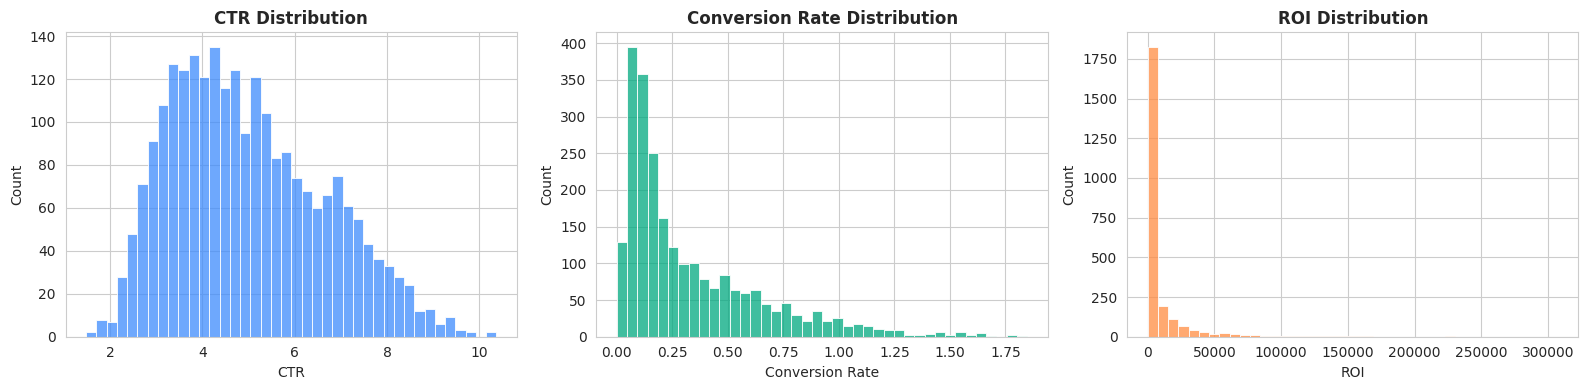

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["CTR"], bins=40, ax=axes[0], color="#3D8BFD")
axes[0].set_title("CTR Distribution")
sns.histplot(df["Conversion Rate"], bins=40, ax=axes[1], color="#00A97F")
axes[1].set_title("Conversion Rate Distribution")
sns.histplot(df["ROI"], bins=40, ax=axes[2], color="#FF8C42")
axes[2].set_title("ROI Distribution")
plt.tight_layout()
plt.show()


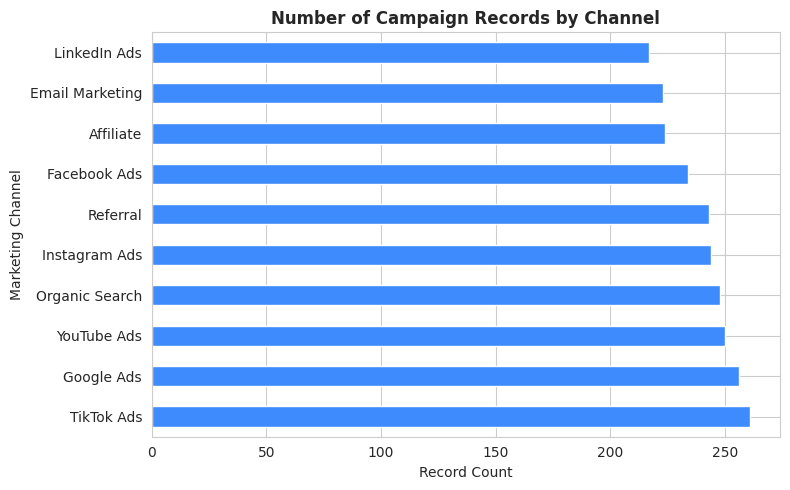

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
df["Marketing Channel"].value_counts().plot(kind="barh", ax=ax, color="#3D8BFD")
ax.set_title("Number of Campaign Records by Channel")
ax.set_xlabel("Record Count")
plt.tight_layout()
plt.show()


## 3. Feature Engineering

In [8]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)
df["Weekday"] = df["Date"].dt.day_name()
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)

df["Click_to_Visit_Rate"] = (df["Landing Page Visits"] / df["Clicks"]).replace([np.inf, -np.inf], 0)
df["Visit_to_Lead_Rate"] = (df["Leads"] / df["Landing Page Visits"]).replace([np.inf, -np.inf], 0)
df["Lead_to_Qualified_Rate"] = (df["Qualified Leads"] / df["Leads"]).replace([np.inf, -np.inf], 0)
df["Qualified_to_Customer_Rate"] = (df["Customers"] / df["Qualified Leads"]).replace([np.inf, -np.inf], 0)
df["Profit"] = df["Revenue"] - df["Cost"]
df["Cost_per_Lead"] = (df["Cost"] / df["Leads"]).replace([np.inf, -np.inf], 0)
df["Avg_Order_Value"] = (df["Revenue"] / df["Customers"]).replace([np.inf, -np.inf], 0)

df[["Click_to_Visit_Rate", "Visit_to_Lead_Rate", "Lead_to_Qualified_Rate",
    "Qualified_to_Customer_Rate", "Profit", "Cost_per_Lead", "Avg_Order_Value"]].describe().T


,count,mean,std,min,25%,50%,75%,max
Click_to_Visit_Rate,2400.0,0.864940,0.071067,0.576512,0.815285,0.868642,0.919631,0.989969
Visit_to_Lead_Rate,2400.0,0.302257,0.098700,0.029451,0.228363,0.295901,0.369045,0.642375
Lead_to_Qualified_Rate,2400.0,0.563497,0.113795,0.000000,0.482948,0.563908,0.641182,0.912281
Qualified_to_Customer_Rate,2399.0,0.353775,0.111512,0.000000,0.277778,0.351648,0.428979,0.744615
Profit,2400.0,10700.348229,14863.706464,-687.240000,1503.167500,4875.730000,14347.317500,164839.720000
Cost_per_Lead,2400.0,3.447001,3.503557,0.021611,0.404684,2.939946,4.645990,69.110000
Avg_Order_Value,2395.0,156.163783,84.419779,35.068571,98.718610,141.230000,189.116827,518.747568


## 4. Conversion (Funnel) Analysis

In [9]:
funnel_totals = df[funnel_cols].sum()
funnel_pct_of_top = (funnel_totals / funnel_totals.iloc[0] * 100).round(2)

funnel_table = pd.DataFrame({
    "Stage": funnel_cols,
    "Total": funnel_totals.values,
    "% of Impressions": funnel_pct_of_top.values,
})
funnel_table


,Stage,Total,% of Impressions
0,Impressions,47712216,100.00
1,Clicks,2383083,4.99
2,Landing Page Visits,2084126,4.37
3,Leads,675852,1.42
4,Qualified Leads,402933,0.84
5,Customers,161129,0.34


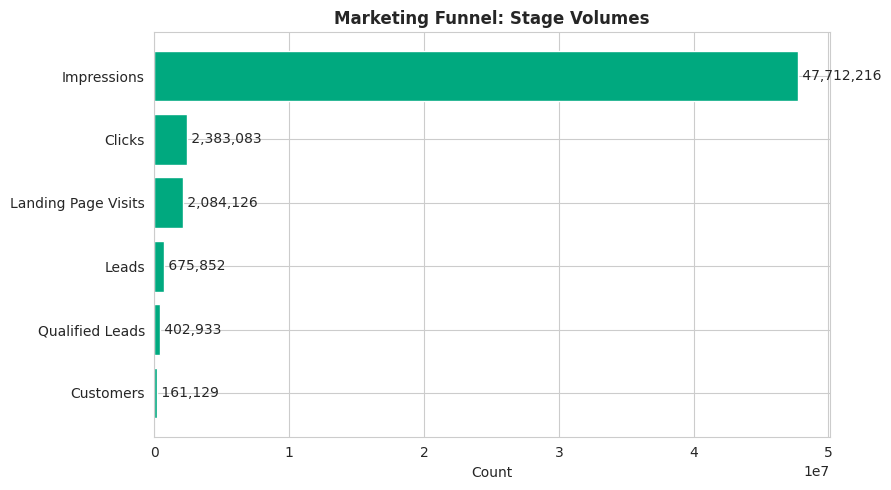

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(funnel_table["Stage"][::-1], funnel_table["Total"][::-1], color="#00A97F")
ax.set_title("Marketing Funnel: Stage Volumes")
ax.set_xlabel("Count")
for i, v in enumerate(funnel_table["Total"][::-1]):
    ax.text(v, i, f" {v:,.0f}", va="center")
plt.tight_layout()
plt.show()


## 5. Drop-off Analysis

In [11]:
funnel_table["Stage-over-Stage Retention (%)"] = (
    funnel_table["Total"] / funnel_table["Total"].shift(1) * 100
).round(2)
funnel_table.loc[0, "Stage-over-Stage Retention (%)"] = 100.0
funnel_table["Drop-off (%)"] = (100 - funnel_table["Stage-over-Stage Retention (%)"]).round(2)
funnel_table.loc[0, "Drop-off (%)"] = 0.0

biggest_dropoff = funnel_table.iloc[1:].sort_values("Drop-off (%)", ascending=False).iloc[0]
print(f"Biggest drop-off stage: {biggest_dropoff['Stage']} ({biggest_dropoff['Drop-off (%)']:.1f}% loss)")
funnel_table


Biggest drop-off stage: Clicks (95.0% loss)


,Stage,Total,% of Impressions,Stage-over-Stage Retention (%),Drop-off (%)
0,Impressions,47712216,100.00,100.00,0.00
1,Clicks,2383083,4.99,4.99,95.01
2,Landing Page Visits,2084126,4.37,87.46,12.54
3,Leads,675852,1.42,32.43,67.57
4,Qualified Leads,402933,0.84,59.62,40.38
5,Customers,161129,0.34,39.99,60.01


## 6. Channel Analysis

In [12]:
channel_summary = df.groupby("Marketing Channel").agg(
    Impressions=("Impressions", "sum"),
    Clicks=("Clicks", "sum"),
    Leads=("Leads", "sum"),
    Qualified_Leads=("Qualified Leads", "sum"),
    Customers=("Customers", "sum"),
    Revenue=("Revenue", "sum"),
    Cost=("Cost", "sum"),
).reset_index()

channel_summary["CTR (%)"] = (channel_summary["Clicks"] / channel_summary["Impressions"] * 100).round(2)
channel_summary["Lead Conv (%)"] = (channel_summary["Leads"] / channel_summary["Clicks"] * 100).round(2)
channel_summary["Customer Conv (%)"] = (channel_summary["Customers"] / channel_summary["Leads"] * 100).round(2)
channel_summary["ROI (%)"] = ((channel_summary["Revenue"] - channel_summary["Cost"]) / channel_summary["Cost"] * 100).round(2)
channel_summary.sort_values("Revenue", ascending=False)


,Marketing Channel,Impressions,Clicks,Leads,Qualified_Leads,Customers,Revenue,Cost,CTR (%),Lead Conv (%),Customer Conv (%),ROI (%)
7,Referral,4973908,344004,141756,99330,49009,9217309.24,21012.59,6.92,41.21,34.57,43765.65
1,Email Marketing,4465345,337910,125128,75283,31475,4605593.30,37141.96,7.57,37.03,25.15,12299.97
3,Google Ads,5088223,314060,94161,58549,22375,3749091.70,357674.80,6.17,29.98,23.76,948.18
5,LinkedIn Ads,4190931,117029,31281,20949,9207,3111751.54,283844.55,2.79,26.73,29.43,996.29
6,Organic Search,4881160,268560,89872,51965,20717,2962792.98,20827.27,5.50,33.46,23.05,14125.55
2,Facebook Ads,4607137,204802,48588,26050,8477,1154473.72,148776.91,4.45,23.72,17.45,675.98
0,Affiliate,4328153,176200,39888,20660,6375,726459.67,103974.19,4.07,22.64,15.98,598.69
4,Instagram Ads,4841248,183057,35084,17905,5198,646277.94,125355.37,3.78,19.17,14.82,415.56
9,YouTube Ads,5006382,167757,28933,13913,3773,463623.54,149428.40,3.35,17.25,13.04,210.26
8,TikTok Ads,5329729,269704,41161,18329,4523,419532.27,128034.11,5.06,15.26,10.99,227.67


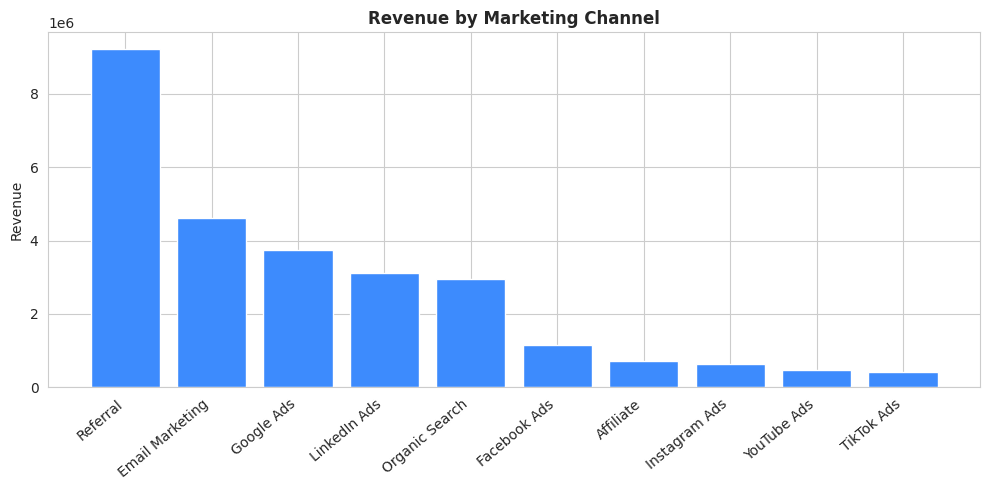

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ordered = channel_summary.sort_values("Revenue", ascending=False)
ax.bar(ordered["Marketing Channel"], ordered["Revenue"], color="#3D8BFD")
ax.set_title("Revenue by Marketing Channel")
ax.set_ylabel("Revenue")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


## 7. ROI Analysis

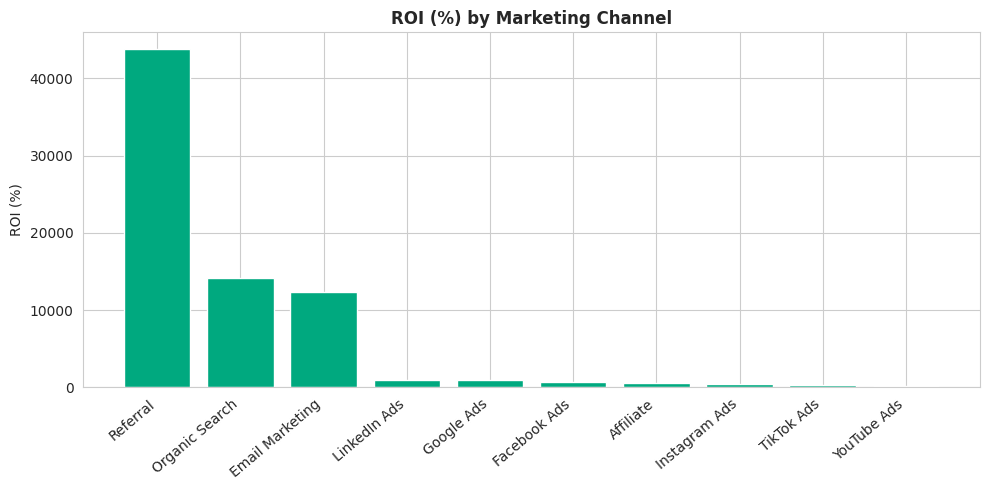

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ordered_roi = channel_summary.sort_values("ROI (%)", ascending=False)
colors = ["#00A97F" if v >= 0 else "#FF5C5C" for v in ordered_roi["ROI (%)"]]
ax.bar(ordered_roi["Marketing Channel"], ordered_roi["ROI (%)"], color=colors)
ax.set_title("ROI (%) by Marketing Channel")
ax.set_ylabel("ROI (%)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


In [15]:
campaign_summary = df.groupby("Campaign").agg(
    Revenue=("Revenue", "sum"), Cost=("Cost", "sum"), Customers=("Customers", "sum")
).reset_index()
campaign_summary["ROI (%)"] = ((campaign_summary["Revenue"] - campaign_summary["Cost"]) / campaign_summary["Cost"] * 100).round(2)
campaign_summary.sort_values("ROI (%)", ascending=False).head(10)


,Campaign,Revenue,Cost,Customers,ROI (%)
1,App Install Campaign,1513689.47,61908.75,8909,2345.03
16,Product Launch Q1,1470642.42,62106.85,8619,2267.92
15,New Year Kickoff,1428852.73,60831.01,8049,2248.89
2,Back to School,1545031.72,66828.14,9055,2211.95
11,Influencer Collab,1257836.60,56302.22,7786,2134.08
0,Anniversary Sale,1649580.30,75217.45,9314,2093.08
19,Summer Sale Blast,1287676.35,59697.23,8008,2057.01
5,Clearance Blowout,1326517.17,66143.15,8566,1905.52
8,Flash Weekend Deal,1502347.82,78291.73,8607,1818.91
18,Referral Bonanza,1025742.52,54380.24,6560,1786.24


## 8. Revenue Analysis

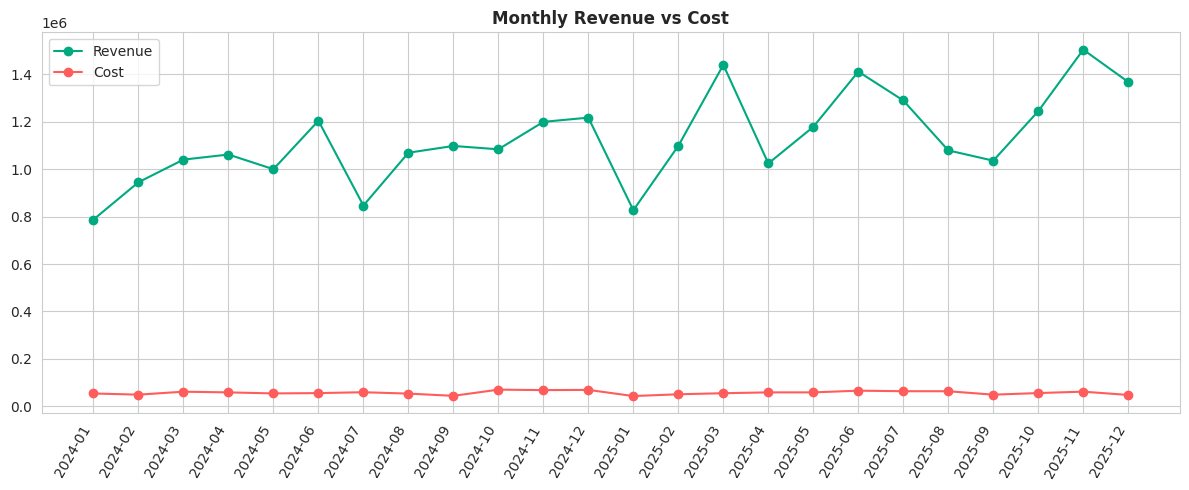

In [16]:
monthly_revenue = df.groupby("Month").agg(Revenue=("Revenue", "sum"), Cost=("Cost", "sum")).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_revenue["Month"], monthly_revenue["Revenue"], marker="o", label="Revenue", color="#00A97F")
ax.plot(monthly_revenue["Month"], monthly_revenue["Cost"], marker="o", label="Cost", color="#FF5C5C")
ax.set_title("Monthly Revenue vs Cost")
ax.legend()
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


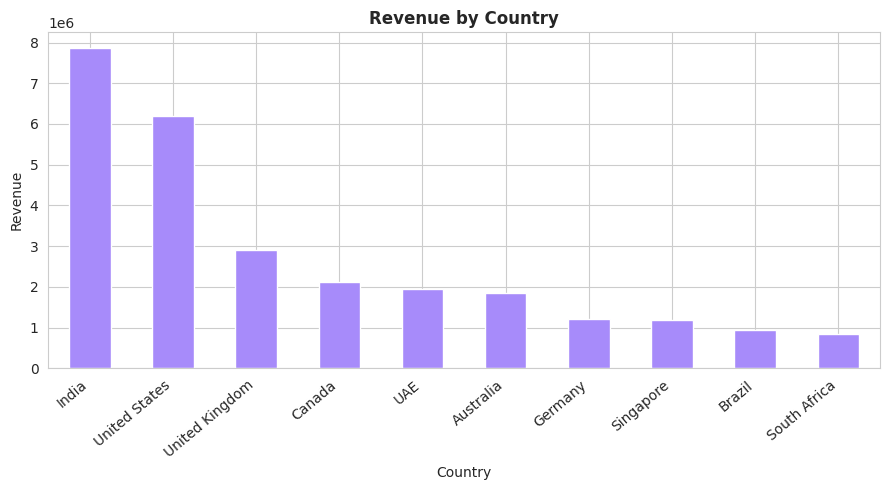

In [17]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
country_revenue.plot(kind="bar", ax=ax, color="#A78BFA")
ax.set_title("Revenue by Country")
ax.set_ylabel("Revenue")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


## 9. Final Business Insights

In [18]:
best_channel = channel_summary.sort_values("Customer Conv (%)", ascending=False).iloc[0]
worst_channel = channel_summary.sort_values("Customer Conv (%)", ascending=True).iloc[0]
best_roi_channel = channel_summary.sort_values("ROI (%)", ascending=False).iloc[0]
best_campaign = campaign_summary.sort_values("ROI (%)", ascending=False).iloc[0]
worst_campaign = campaign_summary.sort_values("ROI (%)", ascending=True).iloc[0]

print("FINAL BUSINESS INSIGHTS")
print("=" * 60)
print(f"1. Highest converting channel : {best_channel['Marketing Channel']} "
      f"({best_channel['Customer Conv (%)']:.2f}% lead-to-customer)")
print(f"2. Lowest performing channel  : {worst_channel['Marketing Channel']} "
      f"({worst_channel['Customer Conv (%)']:.2f}% lead-to-customer)")
print(f"3. Highest ROI channel        : {best_roi_channel['Marketing Channel']} "
      f"({best_roi_channel['ROI (%)']:.1f}% ROI)")
print(f"4. Largest funnel drop-off    : {biggest_dropoff['Stage']} "
      f"({biggest_dropoff['Drop-off (%)']:.1f}% loss)")
print(f"5. Best campaign by ROI       : {best_campaign['Campaign']} "
      f"({best_campaign['ROI (%)']:.1f}% ROI)")
print(f"6. Worst campaign by ROI      : {worst_campaign['Campaign']} "
      f"({worst_campaign['ROI (%)']:.1f}% ROI)")
print(f"7. Top revenue country        : {country_revenue.index[0]} "
      f"(₹{country_revenue.iloc[0]:,.0f})")


FINAL BUSINESS INSIGHTS
1. Highest converting channel : Referral (34.57% lead-to-customer)
2. Lowest performing channel  : TikTok Ads (10.99% lead-to-customer)
3. Highest ROI channel        : Referral (43765.7% ROI)
4. Largest funnel drop-off    : Clicks (95.0% loss)
5. Best campaign by ROI       : App Install Campaign (2345.0% ROI)
6. Worst campaign by ROI      : Brand Awareness Drive (1527.6% ROI)
7. Top revenue country        : India (₹7,857,152)


### Recommendations

1. Improve landing page UX to reduce visitor-to-lead drop-off.
2. Increase budget allocation to the highest-ROI channel identified above.
3. Reduce spend on the lowest-ROI channel or restructure its targeting.
4. Set up retargeting campaigns for landing-page visitors who did not convert to leads.
5. Run structured A/B tests on landing pages, CTAs, and ad creatives.
6. Reduce cost-per-lead by shifting incremental budget toward organic/referral channels.
7. Tighten lead qualification criteria to improve the qualified-to-customer conversion rate.
8. Introduce loyalty and referral incentives to raise customer lifetime value.
9. Personalize campaigns by device and age-group based on observed skews.
10. Monitor monthly revenue-vs-cost trends to catch seasonal ROI dips early.
